In [1]:
%matplotlib widget
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import matplotlib.colors as mcolors
from matplotlib.colors import LogNorm
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec

In [2]:
plt.rcParams.update({
    "font.size": 13,
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "DejaVu Sans", "Liberation Sans"],
    "axes.titlesize": 15,
    "axes.labelsize": 14,
    "legend.fontsize": 12,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
})

In [18]:
# path_to_file = Path('/Users/matheussilva/Documents/meetings_notes/paper_post_processed_data')
path_to_file = Path('/media/matheustolen/Seagate Basic/paper_post_processed_data')
path_fig     = Path("/media/matheustolen/Seagate Basic/cloud-statistics-data/products/figures")

In [4]:
# Read all data in path to file and put then in a dictionary with the name of the file as key:
data = {}
for file in path_to_file.glob('*.nc'):
    data[file.stem] = xr.open_dataset(file)

In [5]:
# Print the keys of the dictionary:
for key in data.keys():
    print(key)

atmosphere_classification
cloud_macrophysics_corrected_by_attenuation
cloud_occurence_per_cloud_type
medians_der_for_Liquid-Precipitable_by_month
medians_der_for_Liquid-Precipitable_by_season
medians_der_for_Liquid_by_month
medians_der_for_Liquid_by_season
medians_der_for_Mixed-Phase-Precipitable_by_month
medians_der_for_Mixed-Phase-Precipitable_by_season
medians_der_for_Mixed-Phase_by_month
medians_der_for_Mixed-Phase_by_season
medians_ier_for_Ice-Precipitable_by_month
medians_lwc_for_Liquid_by_month
medians_lwc_for_Liquid_by_season
medians_lwc_for_Mixed-Phase-Precipitable_by_month
medians_lwc_for_Mixed-Phase-Precipitable_by_season
medians_lwc_for_Mixed-Phase_by_month
medians_lwc_for_Mixed-Phase_by_season
monthly_der_for_Liquid-Precipitable_ndata_per_height_coarsen
monthly_der_for_Liquid-Precipitable_ndata_per_height_orig
monthly_der_for_Liquid-Precipitable_ndata_per_height_resampled
monthly_der_for_Liquid_ndata_per_height_coarsen
q25_lwc_for_Mixed-Phase-Precipitable_by_season
q25_lwc

In [6]:
def filter_by_cdf(array, threshold):
    # Sort in descending order
    sorted_vals = np.sort(array)[::-1]
    cumsum = np.cumsum(sorted_vals)
    cdf = cumsum / cumsum[-1]  # Normalize
    mask = cdf <= threshold
    filtered = np.where(mask, sorted_vals, np.nan)
    return filtered

def mask_cdf_threshold(original_profile, threshold):
    # Save original indices
    original_indices = np.arange(original_profile.size)

    # Sort values (descending), keeping the sorted indices
    sorted_indices = np.argsort(original_profile)[::-1]
    sorted_vals = original_profile[sorted_indices]

    # Handle all-NaN or zero total
    total = np.nansum(sorted_vals)
    if total == 0 or np.isnan(total):
        return np.full_like(original_profile, False, dtype=bool)

    cumsum = np.nancumsum(sorted_vals)
    cdf = cumsum / total

    # Mask: values that contribute up to threshold
    keep_sorted = cdf <= threshold

    # Map mask back to original order
    keep_original = np.full_like(original_profile, False, dtype=bool)
    keep_original[sorted_indices[keep_sorted]] = True

    return keep_original

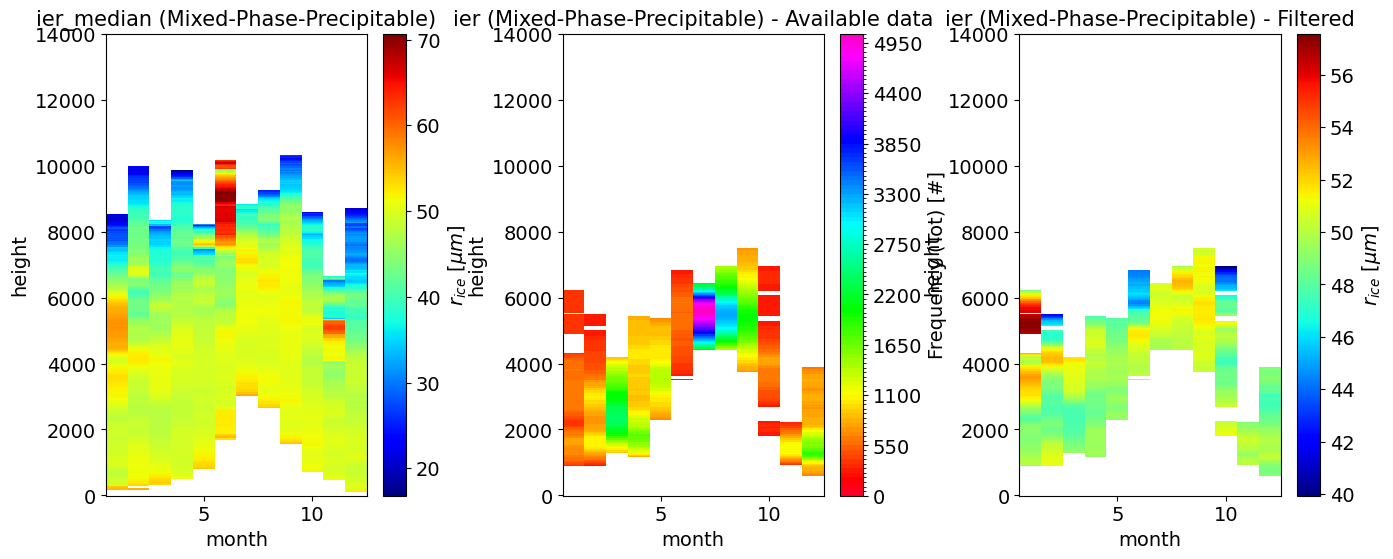

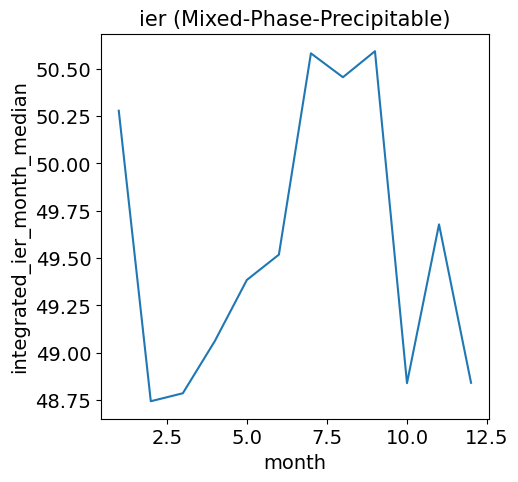

integrated_ier_annual_median: 49.60685729980469


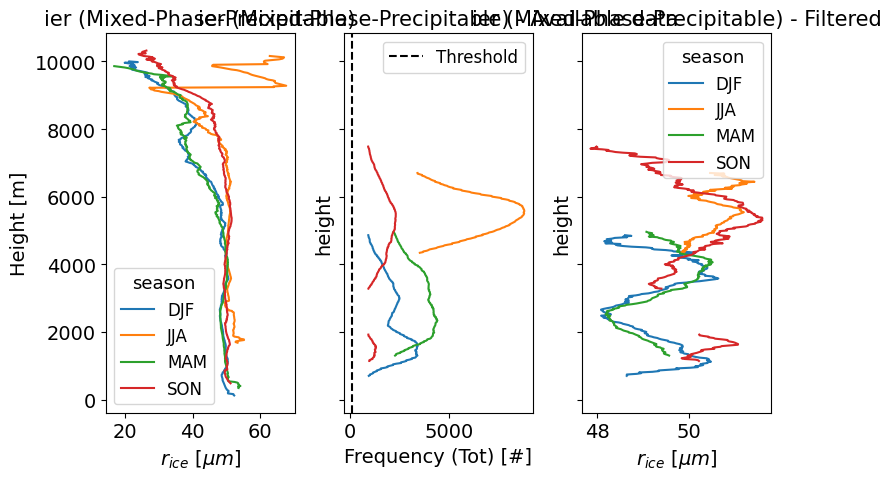

In [7]:
cloud = "Mixed-Phase-Precipitable"
micro = "ier"
key_0 = f"medians_{micro}_for_{cloud}_by_month"
ds_0 = data[key_0]
key_01 = f"monthly_{micro}_for_{cloud}_ndata_per_height_orig"
ds_01 = data[key_01]
key_02 = f"monthly_{micro}_for_{cloud}_ndata_per_height_resampled"
ds_02 = data[key_02]

# ----------------------------------------------------------------------------------------------------------
# months = np.unique(ds_02['time.month'].values)
# fig, axs = plt.subplots(3, 4, figsize=(20, 12), sharey=True, sharex=True)
# axs = axs.flatten()

# for i, month in enumerate(months):
#     print(f"Month: {month}")
#     ax = axs[i]
#     max_val_month_year = ds_02.sel(time=(ds_02['time.month'] == month)).sum()
#     # max_val_month_year = ds_02.sel(time=(ds_02['time.month'] == month)).max(dim='height')
#     ds_02_month        = ds_02.sel(time=(ds_02['time.month'] == month))
#     mask_data = ds_02_month.sum(dim="height")[micro].values > 0
    
#     if not np.any(mask_data):
#         print(f"No data for month {month}, skipping...")
#         continue
#     # Filter data for the current month
    
#     # Normalize the data by the maximum value for this month and year
#     # Drop times where mask_data is False
#     ds_02_month = ds_02_month.isel(time=mask_data)
#     ds_02_month_norm   = (ds_02_month[micro] / max_val_month_year)
#     ds_02_month_norm[micro].plot(y="height", hue="time", ax=ax)
    
#     # -------------------------------------------------------------------------------------------
#     # CV with weighted mean and variance:
#     # --------------------------------------------------------------------------------------------
#     # weights = ds_02_month[micro].isel(time=mask_data)
#     # weighted_mean = (weights * ds_02_month_norm[micro]).sum(dim='time') / weights.sum(dim='time')
#     # deviation = ds_02_month_norm[micro] - weighted_mean
#     # weighted_variance = ((weights * deviation** 2).sum(dim='time') / weights.sum(dim='time'))
    
#     # cv = np.sqrt(weighted_variance) / (weighted_mean + 1e-10)  # Adding a small value to avoid division by zero
    
#     # -------------------------------------------------------------------------------------------
#     # CV normal mean and variance:
#     # --------------------------------------------------------------------------------------------
#     cv = ds_02_month[micro].std(dim='time') / ds_02_month[micro].mean(dim='time')
#     # --------------------------------------------------------------------------------------------
#     tot_per_height = ds_02_month[micro].sum(dim='time')
#     freqs          = ds_02_month[micro] / tot_per_height
#     # mask           = freqs.min(dim="time") > 0.0  # Filter out values less than 30% of the total frequency
#     # freqs.where(mask).plot(y="height", hue="time", ax=ax)
#     # freqs.plot(y="height", hue="time", ax=ax)
    
#     # plot the coeficient of variation as a second axis:
#     # Create a twin axis for CV, sharing the y-axis but with x-axis on top
#     # ax2 = ax.twiny()
#     # cv.plot(y="height", ax=ax2, color='k', linestyle='--', label='CV')
#     # ax2.set_xlabel("Coefficient of Variation (CV)")
#     # ax2.xaxis.set_label_position('top')
#     # ax2.xaxis.tick_top()
#     # ax2.legend(loc='upper left')
    
#     # ds_02.sel(time=(ds_02['time.month'] == month))[micro].plot(y="height", hue="time", ax=ax)
#     ax.set_title(f"Month: {month}")
#     ax.set_xlabel("Frequency (Tot) [#]")
#     ax.set_ylim(0, 3000)

# plt.tight_layout()
# plt.show()

# ----------------------------------------------------------------------------------------------------------
# # same plot as above, but for each season instead of months:
# seasons = ['DJF', 'MAM', 'JJA', 'SON']
# fig, axs = plt.subplots(2, 2, figsize=(10, 7), sharey=True, sharex=True)
# axs = axs.flatten()
# for i, season in enumerate(seasons):
#     ax = axs[i]
#     # Select all times for this season
#     ds_02_season = ds_02.sel(time=(ds_02['time.season'] == season))
#     # Extract years for this season
#     years_in_season = ds_02_season['time.year'].values
#     # For each year in this season, plot a line
#     for year in np.unique(years_in_season):
#         ds_02_season_year = ds_02_season.sel(time=(ds_02_season['time.year'] == year))
#         # Normalize by the max for this season and year
#         max_val = ds_02_season_year[micro].sum()
#         if max_val > 0:
#             (ds_02_season_year[micro] / max_val).mean(dim='time').plot(
#                 y="height", ax=ax, label=str(year)
#             )
#     ax.set_title(f"Season: {season}")
#     ax.set_xlabel("Frequency (Tot) [#]")
#     ax.legend(title="Year")
# plt.tight_layout()
# plt.show()

# ----------------------------------------------------------------------------------------------------------
max_val_monthly = ds_01[micro].sum(dim='height')
# ds_01_norm = ds_01[micro]

# Sort and apply the cumulative sum to normalize the data:
ds_01_cumsum = ds_01[micro].cumsum(dim='height')
# Normalize by the total sum per month to get a cumulative distribution from 0 to 1
ds_01_norm = ( ds_01_cumsum / ds_01[micro].sum(dim='height') ).diff('height')*100

# -----------------------------------------------------------------------------------------
# define treshold to filter data:
# -----------------------------------------------------------------------------------------
# max_val_monthly = ds_01[micro].max()
# max_val_monthly = ds_01[micro].max(dim='height')
# tresh_month  = levels[-1] * 0.1  # 10% of the maximum value
# tresh_month  = 0.2

# mask_monthly = ds_01_norm > tresh_month

# ----------------------------------------------------------------------------------------------------------
# Assume: da is a DataArray with dims ("height", "month")
threshold = 0.80

# Apply function across each month (i.e., along height)
mask_01 = xr.apply_ufunc(
    mask_cdf_threshold,
    ds_01[micro].astype(float),  # ensure float to preserve NaNs
    kwargs={"threshold": threshold},
    input_core_dims=[["height"]],
    output_core_dims=[["height"]],
    vectorize=True,
    dask="allowed",
    output_dtypes=[bool],
)

ds_01_norm   = ds_01[micro].where(mask_01)
mask_monthly = mask_01
# --------------------------------------------------------------------------------------------
dc = 50
# levels_1 = np.arange(ds_01[micro].min(), ds_01[micro].max() + dc, dc)
# levels_1 = np.arange(0, 1 + 0.1, 0.1)
levels_1 = np.arange(0, ds_01_norm.max() + dc , dc)
norm   = mcolors.BoundaryNorm(boundaries=levels_1, ncolors=plt.get_cmap('jet').N)

# Plot the data all variables in this dataset:
for var in ds_0.data_vars:
    if ds_0[var].ndim == 0:
        print(f"{var}: {ds_0[var].values}")
    else:
        if micro in ['lwc', 'iwc', 'der', 'ier'] and ds_0[var].ndim == 2:
            if micro in ['lwc', 'iwc']:
                vmin = ds_0[var].min()
                vmax = ds_0[var].max().item()
                norm_0 = LogNorm(vmin=vmin, vmax=vmax)
            else:
                norm_0 = None

            fig, axs = plt.subplots(1, 3, figsize=(16, 6))
            # -----------------------------------------------------------------------------------------------
            im0 = ds_0[var].plot(
                x='month', y='height', cmap='jet',
                vmin=ds_0[var].min(), vmax=ds_0[var].max(),
                norm=norm_0, ax=axs[0], add_colorbar=True
            )
            # -----------------------------------------------------------------------------------------------
            # im1 = ds_01[micro].where(ds_01[micro] != 0).plot(x='month', y='height', cmap='gist_rainbow', norm=norm, ax=axs[1], add_colorbar=True)
            
            im1 = ds_01_norm.where(ds_01[micro] != 0).plot(
                x='month', y='height', cmap='gist_rainbow', norm=norm, ax=axs[1], add_colorbar=True
            )

            if hasattr(im1, 'colorbar') and im1.colorbar is not None:
                im1.colorbar.set_label("Frequency (Tot) [#]")
          
            # -----------------------------------------------------------------------------------------------
            ds_0_filtered = ds_0[var].where(mask_monthly)
            dvar = 25

            # Round vmin down to nearest multiple of 10, vmax up to nearest multiple of 10
            vmin_rounded = np.floor(float(ds_0_filtered.min()) / 10) * 10
            vmax_rounded = np.ceil(float(ds_0_filtered.max()) / 10) * 10
            level_2 = np.arange(vmin_rounded, vmax_rounded + dvar, dvar)
            norm_2 = mcolors.BoundaryNorm(boundaries=level_2, ncolors=plt.get_cmap('jet').N)


            im0_filtered = ds_0_filtered.plot(
                x='month', y='height', cmap='jet', ax=axs[2], add_colorbar=True
            )

            # # Use contourf for a filled contour plot instead of pcolormesh
            # X, Y = np.meshgrid(ds_0_filtered['month'], ds_0_filtered['height'])
            # im0_filtered = axs[2].contourf(
            #     X, Y, ds_0_filtered.T, levels=levels, cmap='jet', norm=norm_0
            # )
            # cbar = plt.colorbar(im0_filtered, ax=axs[2])
            # cbar.set_label(ds_0_filtered.attrs.get("long_name", var))
            
            # -----------------------------------------------------------------------------------------------
            axs[0].set_title(f"{var} ({cloud})")
            axs[1].set_title(f"{micro} ({cloud}) - Available data")
            axs[2].set_title(f"{micro} ({cloud}) - Filtered")
            fig.subplots_adjust(wspace=0.4)
            plt.show()
        else:
            fig, axs = plt.subplots(1, 1, figsize=(5, 5))
            ds_0[var].plot(x='month')
            axs.set_title(f"{micro} ({cloud})")
            plt.show()

key_1 = f"medians_{micro}_for_{cloud}_by_season"
ds_1  = data[key_1]
key_11 = f"seasonal_{micro}_for_{cloud}_ndata_per_height_orig"
ds_11 = data[key_11]

# max_val_seasonal = ds_11[micro].max()
# max_val_seasonal = ds_11[micro].max(dim='height')
max_val_seasonal = ds_11[micro].sum(dim='height')

# ds_11_norm    = ds_11[micro] / max_val_seasonal
ds_11_norm    = ds_11[micro]

# tresh_season  = ds_11_norm.max() * 0.1  # 10% of the maximum value
tresh_season  = 100
mask_seasonal = ds_11_norm > tresh_season

# --------------------------------------------------------------------------------------------
mask_02 = xr.apply_ufunc(
    mask_cdf_threshold,
    ds_11[micro].astype(float),  # ensure float to preserve NaNs
    kwargs={"threshold": threshold},
    input_core_dims=[["height"]],
    output_core_dims=[["height"]],
    vectorize=True,
    dask="allowed",
    output_dtypes=[bool],
)

ds_11_norm   = ds_11[micro].where(mask_02)
mask_seasonal = mask_02

# ---------------------------------------------------------------------------------------------

# Plot the data all variables in this dataset:
for var in ds_1.data_vars:
    fig, axs = plt.subplots(1, 3, figsize=(8, 5), sharey=True)
    ds_1[var].plot.line(y='height', hue='season', ax=axs[0])
    
    
    # ds_11[micro].where(ds_11[micro] != 0).plot.line(y='height', ax=axs[1])
    ds_11_norm.where(ds_11[micro] != 0).plot.line(
        y='height', hue='season', ax=axs[1],
    )

    axs[1].axvline(tresh_season, color='k', linestyle='--', label='Threshold')
    axs[1].legend()
    
    ds_1[var].where(mask_seasonal).plot.line(
        y='height', hue='season', ax=axs[2],
    )
    axs[0].set_ylabel("Height [m]")
    axs[0].set_title(f"{var} ({cloud})")
    axs[1].set_title(f"{micro} ({cloud}) - Available data")
    axs[2].set_title(f"{micro} ({cloud}) - Filtered")
    axs[1].set_xlabel("Frequency (Tot) [#]")
    plt.tight_layout()
    plt.show()


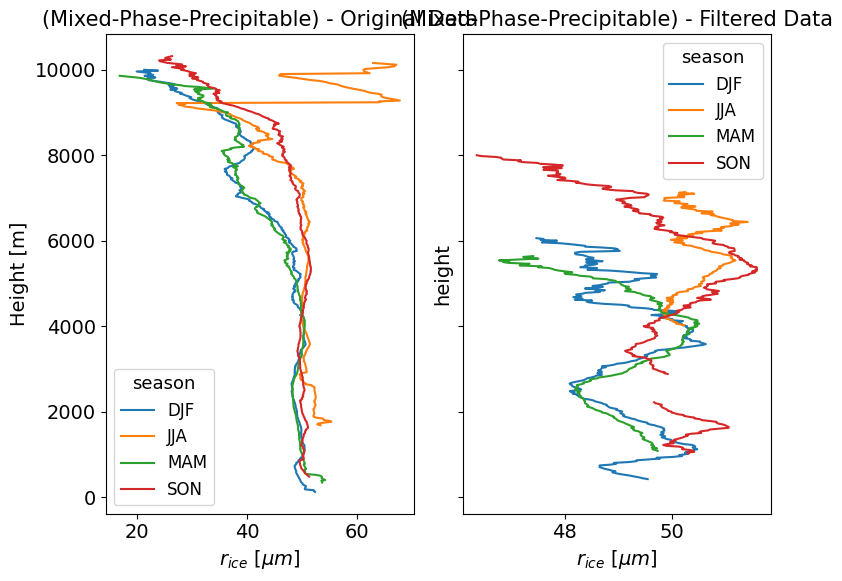

In [8]:
cloud_type = "Mixed-Phase-Precipitable"
var_name   = "ier"

var_stats_seasonal = data[f"stats_{var_name}_for_{cloud_type}_by_season"]
var_stats_monthly = data[f"stats_{var_name}_for_{cloud_type}_by_month"]

nvar_monthly_ds = data[f"monthly_{micro}_for_{cloud}_ndata_per_height_orig"]
nvar_seasonal_ds = data[f"seasonal_{micro}_for_{cloud}_ndata_per_height_orig"]

# --------------------------------------------------------------------------------------------
# Mask based on CDF threshold
# --------------------------------------------------------------------------------------------
threshold = 0.90

# Apply function across each month (i.e., along height)
mask_seasonal = xr.apply_ufunc(
    mask_cdf_threshold,
    nvar_seasonal_ds[micro].astype(float), 
    kwargs={"threshold": threshold},
    input_core_dims=[["height"]],
    output_core_dims=[["height"]],
    vectorize=True,
    dask="allowed",
    output_dtypes=[bool],
)

# plot the data and filtered data side by side
fig, axs = plt.subplots(1, 2, figsize=(8, 6), sharey=True)
# Plot the original data
var_stats_seasonal[f"{var_name}_median"].plot(
    y='height', hue='season', ax=axs[0],
)
# Plot the filtered data
var_stats_seasonal[f"{var_name}_median"].where(mask_seasonal).plot(
    y='height', hue='season', ax=axs[1],
)
axs[0].set_title(f"({cloud_type}) - Original Data")
axs[1].set_title(f"({cloud_type}) - Filtered Data")
axs[0].set_ylabel("Height [m]")
plt.tight_layout()
plt.show()


In [24]:
# cloud_type = ["Mixed-Phase-Precipitable"]
cloud_type = ["Mixed-Phase"]
variables = ["lwc", "iwc", "der", "ier"]

# cloud_type = ["Ice", "Ice-Precipitable"]
# variables = ["iwc",  "ier"]

# cloud_type = ["Liquid", "Liquid-Precipitable"]
# variables = ["lwc", "der"]

unique_cloud_types = np.unique(cloud_type)

# For each unique cloud type, build the lists of keys and merge datasets
ds_seasonal_dict = {}
ds_monthly_dict  = {}
ds_nvars_seasonal_dict = {}
ds_nvars_monthly_dict = {}
ds_npr_monthly_dict = {}

for ct in unique_cloud_types:
    data_vars_seasonal = [f"stats_{var}_for_{ct}_by_season" for var in variables]
    data_vars_monthly = [f"stats_{var}_for_{ct}_by_month" for var in variables]
    data_nvars_seasonal = [f"seasonal_{var}_for_{ct}_ndata_per_height_orig" for var in variables]
    data_nvars_monthly = [f"monthly_{var}_for_{ct}_ndata_per_height_orig" for var in variables]
    data_npr_monthly = [f"monthly_{var}_nprofile_for_{ct}" for var in variables]

    ds_seasonal_dict[ct] = xr.merge([data[var] for var in data_vars_seasonal if var in data])
    ds_monthly_dict[ct] = xr.merge([data[var] for var in data_vars_monthly if var in data])
    ds_nvars_seasonal_dict[ct] = xr.merge([data[var] for var in data_nvars_seasonal if var in data])
    ds_nvars_monthly_dict[ct] = xr.merge([data[var] for var in data_nvars_monthly if var in data])
    ds_npr_monthly_dict[ct] = xr.merge([data[var] for var in data_npr_monthly if var in data])
    

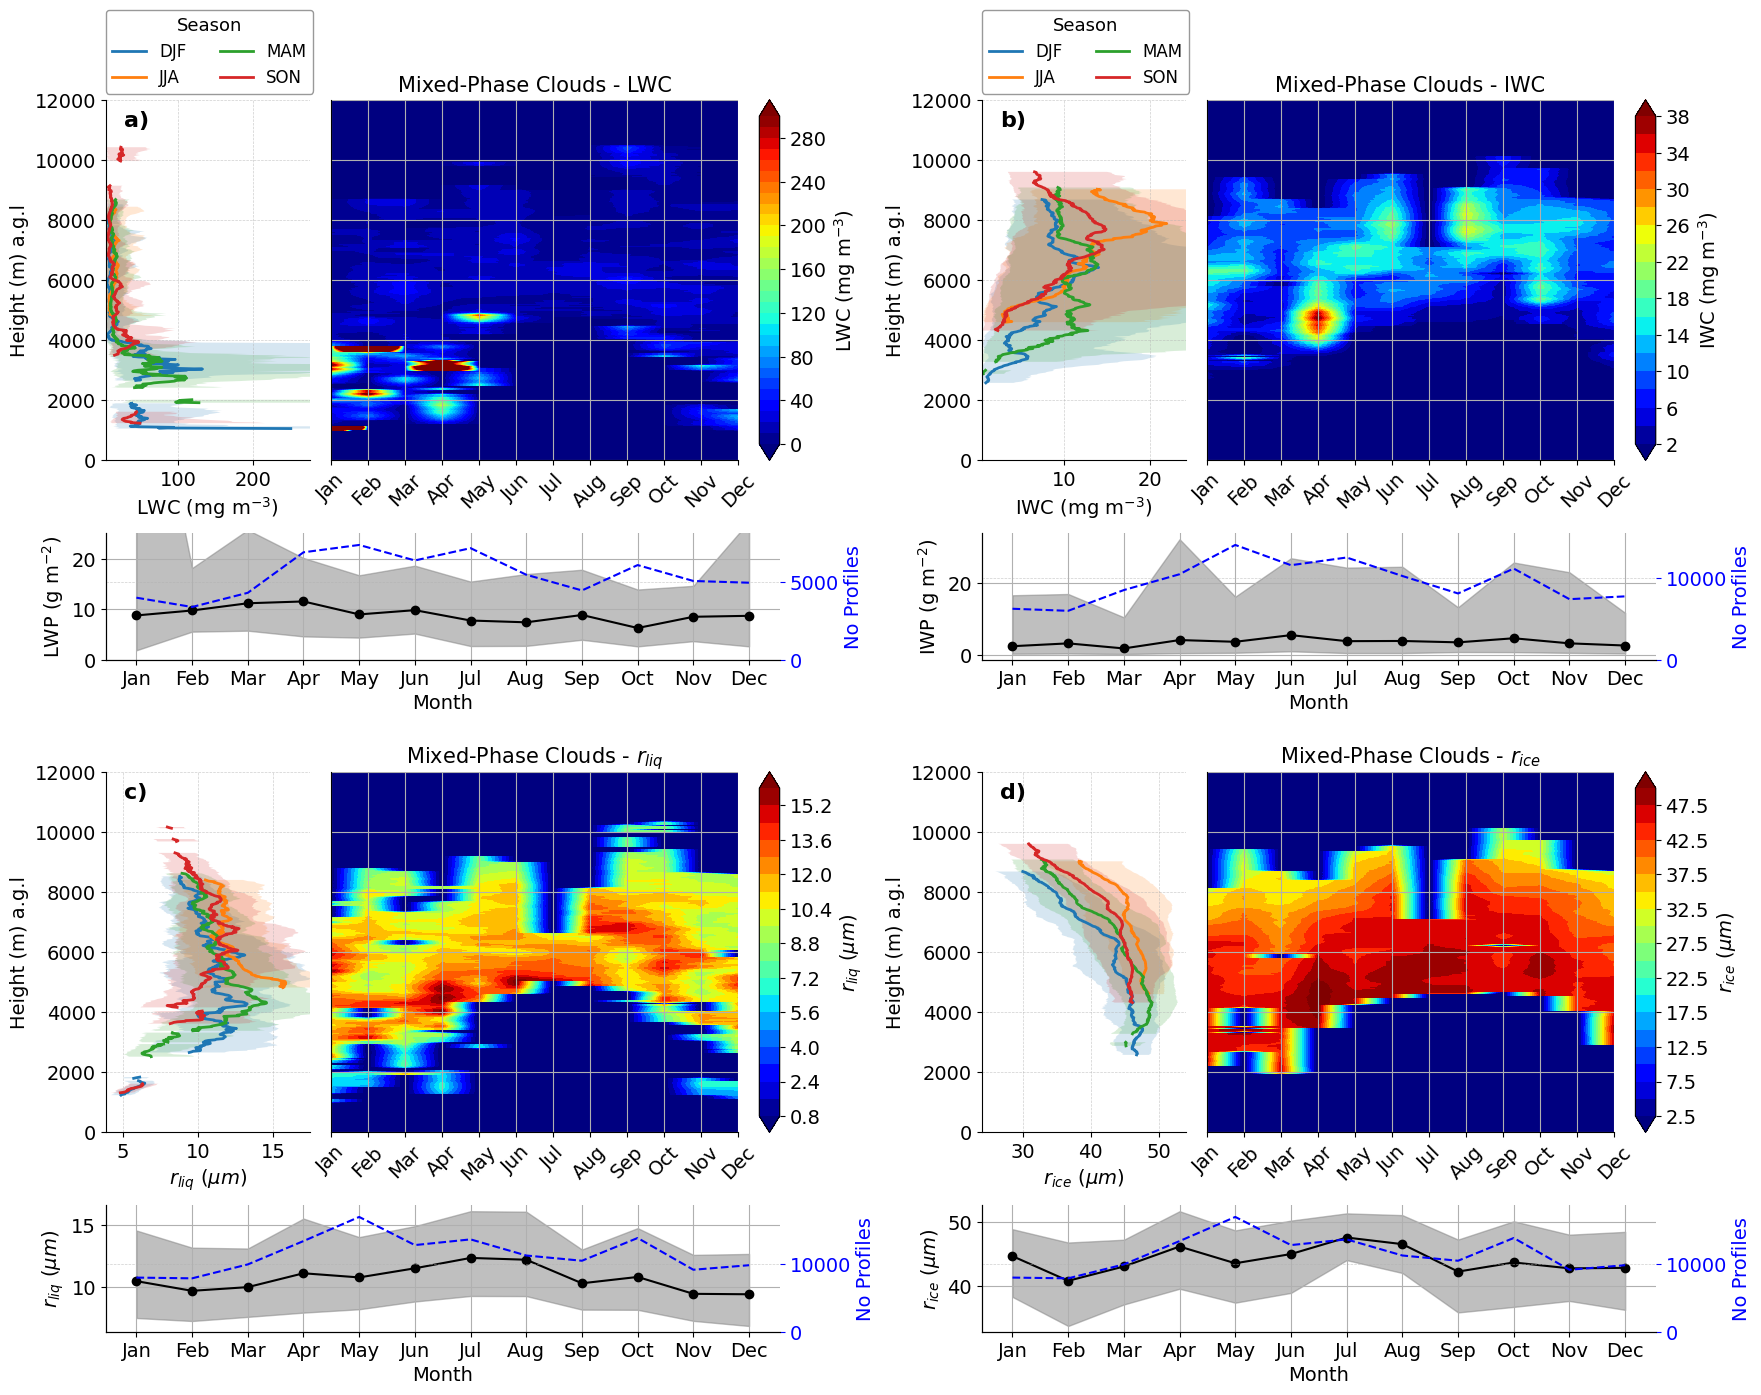

In [28]:
%matplotlib inline
plt.close('all')
season_colors = ['#1b9e77', '#d95f02', '#7570b3', '#e7298a']

# Create a large figure: 2x2 layout for the 4 full variable panels
fig = plt.figure(figsize=(20, 16))
outer_gs = gridspec.GridSpec(2, 2, wspace=0.3, hspace=0.2)


for ct in unique_cloud_types:
    ds_seasonal = ds_seasonal_dict[ct]
    ds_monthly  = ds_monthly_dict[ct]
    ds_nvars_seasonal = ds_nvars_seasonal_dict[ct]
    ds_nvars_monthly  = ds_nvars_monthly_dict[ct]
    ds_npr_monthly = ds_npr_monthly_dict[ct]

    for idx, var_name in enumerate(variables):
        # Row, col position in 2x2 layout

        if ct == "Mixed-Phase" or ct == "Mixed-Phase-Precipitable":
            row, col = divmod(idx, 2)
        
        elif ct == unique_cloud_types[0]:
            row, col = idx, 0
        else:
            row, col = idx, 1
        
        # print(row, col, ct, var_name)

        # SubGridSpec inside each panel (2 rows x 3 columns)
        gs = gridspec.GridSpecFromSubplotSpec(
            2, 3, 
            subplot_spec=outer_gs[row, col], 
            width_ratios=[1, 2, 0.1], 
            height_ratios=[2, .7],
            wspace=0.1, hspace=0.3
        )

        ax0 = fig.add_subplot(gs[0, 0])  # Seasonal plot
        ax1 = fig.add_subplot(gs[0, 1], sharey=ax0)  # Monthly contour plot
        cax1 = fig.add_subplot(gs[0, 2])  # Colorbar
        ax2 = fig.add_subplot(gs[1, 0:])   # Integrated plot (spanning all columns)
        ax2a = ax2.twinx()  # Create a twin axis for the integrated plot

        # Add subplot label (a), (b), (c), (d)
        # label = chr(ord('a') + row + col * 2)
        label_order = ['a', 'c', 'b', 'd']
        label = label_order[row + col * 2]
        ax0.text(0.09, 0.97, f"{label})", transform=ax0.transAxes,
                fontsize=16, fontweight='bold', va='top', ha='left')

        # --------------------------------------------------------------------------------
        # Masking
        # --------------------------------------------------------------------------------
        # ------------------------------------------------------------------------------------------------
        threshold = 0.90
        
        mask_seasonal = xr.apply_ufunc(
            mask_cdf_threshold,
            ds_nvars_seasonal[var_name].astype(float),
            kwargs={"threshold": threshold},
            input_core_dims=[["height"]],
            output_core_dims=[["height"]],
            vectorize=True,
            dask="allowed",
            output_dtypes=[bool],
        )

        mask_monthly = xr.apply_ufunc(
            mask_cdf_threshold,
            ds_nvars_monthly[var_name].astype(float),
            kwargs={"threshold": threshold},
            input_core_dims=[["height"]],
            output_core_dims=[["height"]],
            vectorize=True,
            dask="allowed",
            output_dtypes=[bool],
        )
        # --------------------------------------------------------------------------------
        # Set levels and xlim based on cloud type and variable
        # --------------------------------------------------------------------------------
        levels = 20
        integrated_xlim = None
        seasonal_pr_xlim = None
        if ct == "Liquid":
            if var_name == 'lwc':
                levels = np.arange(0, 300 + 10, 10)
            elif var_name == 'der':
                levels = np.arange(0, 10 + .5, .5)
                seasonal_pr_xlim = (2, 7)
                integrated_xlim = (4, 7)
        
        if ct == "Liquid-Precipitable":
            if var_name == 'lwc':
                levels = np.arange(0, 300 + 10, 10)
            elif var_name == 'der':
                levels = np.arange(0, 10 + .5, .5)
                seasonal_pr_xlim = (2, 12)
                integrated_xlim = (4, 12)
        
        if ct == "Mixed-Phase":
            if var_name == 'lwc':
                levels = np.arange(0, 300 + 10, 10)
                # levels = np.arange(0, 50 + 5, 5)
                integrated_xlim = (0, 25)

        if ct == "Ice" or ct == "Ice-Precipitable":
            if var_name == 'ier':
                print("Using IER levels")
                levels = np.arange(0, 60 + 2, 2)
                seasonal_pr_xlim = (20, 60)
                integrated_xlim = (30, 60)

        # --------------------------------------------------------------------------------
        # Seasonal profile
        # --------------------------------------------------------------------------------
        ds_seasonal[f"{var_name}_median"].where(mask_seasonal).plot(
            y='height', hue='season', ax=ax0, linestyle='-', linewidth=2,
        )

        for season in ds_seasonal['season'].values:
            ax0.fill_betweenx(
                ds_seasonal['height'],
                ds_seasonal[f"{var_name}_q25"].where(mask_seasonal).sel(season=season),
                ds_seasonal[f"{var_name}_q75"].where(mask_seasonal).sel(season=season),
                alpha=0.18,
            )

        # ax0.set_title("Seasonal Profiles")
        ax0.set_xlabel(f"{ds_seasonal[f'{var_name}_median'].attrs['long_name']} ({ds_seasonal[f'{var_name}_median'].attrs['units']})")
        ax0.set_ylabel("Height (m) a.g.l")
        
        if ct == "Liquid" or ct == "Liquid-Precipitable":
            ax0.set_ylim(0, 6000)  # Set y-axis limits for liquid clouds
        else:
            ax0.set_ylim(0, 12000)

        ax0.set_xlim(ds_seasonal[f"{var_name}_median"].where(mask_seasonal).min().item() * 0.8,
                    ds_seasonal[f"{var_name}_median"].where(mask_seasonal).max().item() * 1.1)  # Set x-axis limits
        ax0.grid(True, linestyle='--', linewidth=0.5, alpha=0.6)
        
        # add label to the legend
        handles, labels = ax0.get_legend_handles_labels()
        if not handles:
            # If empty, manually create legend from the seasonal lines
            lines = ax0.get_lines()
            seasons = ds_seasonal['season'].values
            handles = [lines[i] for i in range(len(seasons))]
            labels = [str(season) for season in seasons]
        if row == 0:
            ax0.legend(handles, 
                    labels, 
                    title="Season", 
                    loc='upper left', 
                    bbox_to_anchor=(0.0, 1.25), 
                    borderaxespad=0., 
                    ncol=2,
                    edgecolor='gray')
        else:
            ax0.legend_.remove() if ax0.legend_ is not None else None
        ax0.set_xlim(seasonal_pr_xlim)
        # --------------------------------------------------------------------------------
        # Monthly contour plot
        # --------------------------------------------------------------------------------
        data_masked = ds_monthly[f"{var_name}_median"].where(mask_monthly).fillna(0.0)
        # # add nans to zero values to avoid plotting them in the contourf
        # data_masked = data_masked.where(data_masked != 0.0)
        pcm = ax1.contourf(
            ds_monthly[f"{var_name}_median"]['month'],
            ds_monthly[f"{var_name}_median"]['height'],
            data_masked.T.values,
            levels= levels,
            cmap='jet',
            extend='both',
        )

        # ax1.set_title(f"{ds_seasonal[f'{var_name}_median'].attrs['long_name']} Monthly Profiles")
        ax1.set_xticks(np.arange(1, 13))
        ax1.set_xticklabels(["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                            "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"], rotation=45)
        ax1.tick_params(axis='y', left=False, labelleft=False)
        ax1.grid(True)

        if ct == "Liquid-Precipitable":
            ax1.set_title(f"Precipitating-Liquid Clouds - {ds_monthly[f'{var_name}_median'].attrs['long_name']}")
        elif ct == "Mixed-Phase-Precipitable":
            ax1.set_title(f"Precipitating-Mixed-Phase Clouds - {ds_monthly[f'{var_name}_median'].attrs['long_name']}")
        elif ct == "Ice-Precipitable":
            ax1.set_title(f"Precipitating-Ice Clouds - {ds_monthly[f'{var_name}_median'].attrs['long_name']}")
        else:
            ax1.set_title(f"{ct} Clouds - {ds_monthly[f'{var_name}_median'].attrs['long_name']}")

        cbar = plt.colorbar(pcm, cax=cax1)
        cbar.set_label(f"{ds_seasonal[f'{var_name}_median'].attrs['long_name']} ({ds_monthly[f'{var_name}_median'].attrs['units']})")

        # --------------------------------------------------------------------------------
        # Integrated median
        # --------------------------------------------------------------------------------
        annual_median = ds_monthly[f"integrated_{var_name}_annual_median"].item()
        
        ds_monthly[f"integrated_{var_name}_median"].plot(
            x='month', ax=ax2, marker='o', linestyle='-', color="black",
        )
        
        # Add a horizntal line for the annual median
        # ax2.axhline(annual_median, color='red', linestyle='--', linewidth=1.5, label=f"Annual Median: {annual_median:.2f}"
        #             )

        ax2.fill_between(
            ds_monthly['month'],
            ds_monthly[f"integrated_{var_name}_q25"],
            ds_monthly[f"integrated_{var_name}_q75"],
            alpha=0.5, color='gray'
        )
        ax2.set_ylim(integrated_xlim)
        ax2.set_xlabel("Month")
        ax2.set_ylabel(f"{ds_monthly[f'integrated_{var_name}_median'].attrs['long_name']} ({ds_monthly[f'integrated_{var_name}_median'].attrs['units']})")
        ax2.set_xticks(np.arange(1, 13))
        ax2.set_xticklabels(["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                            "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
        ax2.grid(True)
        # ax2.legend(loc='upper right', borderaxespad=0., edgecolor='gray')

        # Plot number of cases
        ax2a.plot(
            ds_npr_monthly[f"{var_name}"].month,
            ds_npr_monthly[f"{var_name}"].values,
            color='blue', linestyle='--', linewidth=1.5,
        )
        ax2a.set_ylabel("No Profiles", color='blue')
        ax2a.tick_params(axis='y', colors='blue')
        ax2a.set_ylim(0, ds_npr_monthly[f"{var_name}"].max().item() * 1.1)
        ax2a.grid(True, linestyle='--', linewidth=0.5, alpha=0.6)

        # --------------------------------------------------------------------------------
        # Clean aesthetics
        # --------------------------------------------------------------------------------
        for ax in [ax0, ax1, ax2, ax2a]:
            ax.spines['right'].set_visible(False)
            ax.spines['top'].set_visible(False)
  
        
fig.savefig(path_fig / f"{ct}_seasonal_monthly_profiles.png", bbox_inches='tight', dpi=500)
plt.show()


In [11]:
for ct in unique_cloud_types:
    ds_monthly  = ds_monthly_dict[ct]
    print(f"{ct}")
    for idx, var_name in enumerate(variables):
        print(f"{var_name}: {ds_monthly[f'integrated_{var_name}_annual_median'].item()}")
        

Mixed-Phase
lwc: 8.932941436767578
iwc: 3.533621311187744
der: 10.780207633972168
ier: 44.64564895629883


In [12]:
key_0 = "cloud_macrophysics_corrected_by_attenuation"
ds_0 = data[key_0]
print(ds_0.data_vars)

key_1 = "atmosphere_classification"
ds_1 = data[key_1]
print(ds_1.data_vars)

key_2= "cloud_occurence_per_cloud_type"
ds_2 = data[key_2]
print(ds_2.data_vars)

Data variables:
    cloud_base       (time) float64 ...
    cloud_top        (time) float64 ...
    cloud_thickness  (time) float64 ...
Data variables:
    single_layer  (time) float64 ...
    multi_layer   (time) float64 ...
    clear_sky     (time) float64 ...
    noise         (time) float64 ...
    attenuation   (time) bool ...
Data variables:
    Liquid                    (time) float64 ...
    Liquid-Precipitable       (time) float64 ...
    Ice                       (time) float64 ...
    Ice-Precipitable          (time) float64 ...
    Mixed-Phase               (time) float64 ...
    Mixed-Phase-Precipitable  (time) float64 ...
    Noise                     (time) float64 ...
    Attenuation               (time) int64 ...


In [13]:
key_0 = "cloud_macrophysics_corrected_by_attenuation"
ds_0 = data[key_0]
print(ds_0.data_vars)

key_1 = "atmosphere_classification"
ds_1 = data[key_1]
print(ds_1.data_vars)

key_2= "cloud_occurence_per_cloud_type"
ds_2 = data[key_2]
print(ds_2.data_vars)

Data variables:
    cloud_base       (time) float64 ...
    cloud_top        (time) float64 ...
    cloud_thickness  (time) float64 ...
Data variables:
    single_layer  (time) float64 ...
    multi_layer   (time) float64 ...
    clear_sky     (time) float64 ...
    noise         (time) float64 ...
    attenuation   (time) bool ...
Data variables:
    Liquid                    (time) float64 ...
    Liquid-Precipitable       (time) float64 ...
    Ice                       (time) float64 ...
    Ice-Precipitable          (time) float64 ...
    Mixed-Phase               (time) float64 ...
    Mixed-Phase-Precipitable  (time) float64 ...
    Noise                     (time) float64 ...
    Attenuation               (time) int64 ...


In [14]:
key_0 = "cloud_macrophysics_corrected_by_attenuation"
ds_0 = data[key_0]
print(ds_0.data_vars)

key_1 = "atmosphere_classification"
ds_1 = data[key_1]
print(ds_1.data_vars)

key_2= "cloud_occurence_per_cloud_type"
ds_2 = data[key_2]
print(ds_2.data_vars)

Data variables:
    cloud_base       (time) float64 ...
    cloud_top        (time) float64 ...
    cloud_thickness  (time) float64 ...
Data variables:
    single_layer  (time) float64 ...
    multi_layer   (time) float64 ...
    clear_sky     (time) float64 ...
    noise         (time) float64 ...
    attenuation   (time) bool ...
Data variables:
    Liquid                    (time) float64 ...
    Liquid-Precipitable       (time) float64 ...
    Ice                       (time) float64 ...
    Ice-Precipitable          (time) float64 ...
    Mixed-Phase               (time) float64 ...
    Mixed-Phase-Precipitable  (time) float64 ...
    Noise                     (time) float64 ...
    Attenuation               (time) int64 ...


In [15]:
## Mean over the year macrophysics
cloud_types = list(ds_2.data_vars)[:-2]
layer = "single_layer"
macro = "cloud_base"

ds_list = []
to_quit = ds_1.attenuation & ds_1.noise.astype(bool)
for cloud in cloud_types:
    to_keep = ds_2[cloud].values.astype(bool) & ds_1[layer].values.astype(bool)

    if macro == "cloud_thickness":
        ds = ds_0[macro].where(~to_quit).where(to_keep).median()
    else:
        ds = (ds_0[macro] - 680.0).where(~to_quit).where(to_keep).median()
    
    ds_list.append(ds)

ds = xr.concat(ds_list, dim="cloud_type")
ds["cloud_type"] = cloud_types
for var in ds.cloud_type.values:
    print(f"{var}: {ds.sel(cloud_type=var).values}")

Liquid: 1401.1533203125
Liquid-Precipitable: 834.7296142578125
Ice: 7665.8515625
Ice-Precipitable: 1997.388671875
Mixed-Phase: 5553.48388671875
Mixed-Phase-Precipitable: 1530.79443359375


In [16]:
cloud_types = list(ds_2.data_vars)[:-2]
for cloud in cloud_types:
    mean_value = ds_2[cloud].where(ds_1[layer].values.astype(bool), 0).mean()
    print(f"{cloud}: {mean_value.values}")


Liquid: 0.014232022100025552
Liquid-Precipitable: 0.0125119966680952
Ice: 0.049379996096681575
Ice-Precipitable: 0.03628501668970429
Mixed-Phase: 0.03457002130728975
Mixed-Phase-Precipitable: 0.03225468951516359


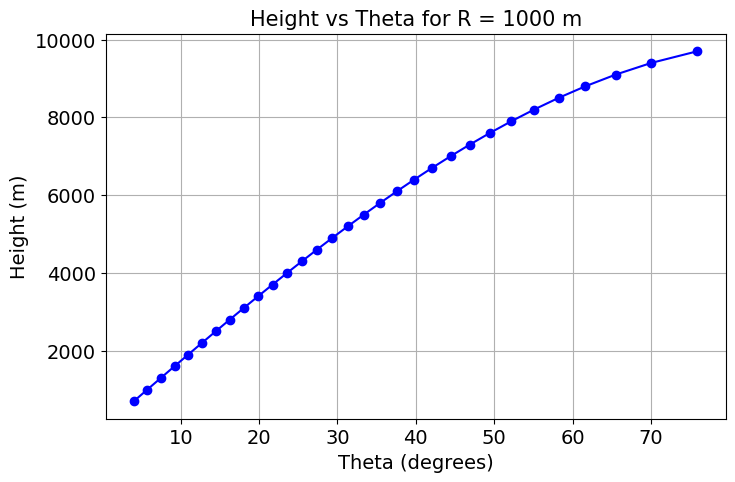

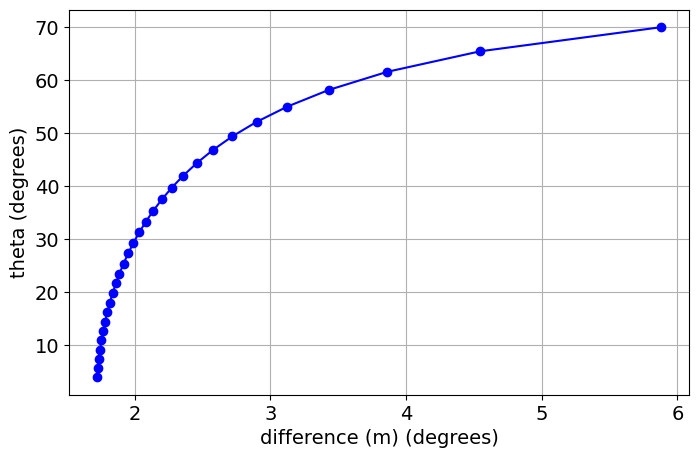

In [17]:

R = 10000
h = np.arange(700, R, 300) # height in meters
elevation  = np.rad2deg( np.arcsin(h/R) )

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(elevation, h, "-o", color='blue')
ax.set_xlabel('Theta (degrees)')
ax.set_ylabel('Height (m)')
ax.set_title('Height vs Theta for R = 1000 m')
ax.grid(True)
plt.show()

# Plot the cloud types
diff_elevation = np.diff(elevation)
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(diff_elevation, elevation[:-1] , "-o", color='blue')
ax.set_xlabel('difference (m) (degrees)')
ax.set_ylabel('theta (degrees)')
ax.grid(True)
plt.show()





In [18]:
# Scans can be faster at high altitudes (higher diference in angles), but not at low altitudes
daz = 355 # degrees
waz = 5 # degrees / s
t1 = daz / waz # seconds
print(f"Time to scan {daz} degrees at {waz} degrees/s: {t1} seconds ({t1/60:.2f} minutes)")

delev = 90-55
w     = delev / t1
print(f"Time to scan {delev} degrees at {w:.2f} degrees/s: {w:.2f} seconds ({t1/60:.2f} minutes)")
# 60-70 the elevatin angle reached its final position faster than the azimuth angle: There is a minimun velocity tha radar can measure, with is around 
# 0.42 - 0.49 degrees/s

Time to scan 355 degrees at 5 degrees/s: 71.0 seconds (1.18 minutes)
Time to scan 35 degrees at 0.49 degrees/s: 0.49 seconds (1.18 minutes)
